# Listen what you won't — Experimento básico

Este notebook recorre el flujo mínimo del proyecto:

1. Generar una red aleatoria con opiniones asignadas
2. Aplicar el modelo HK hasta convergencia
3. Aplicar rewiring homofílico para forzar cámaras de eco
4. Visualizar la red y las métricas en cada fase

---

## 0 · Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from network_gen   import make_network, get_opinions
from hk_dynamics   import hk_run_history, opinion_variance, n_clusters, polarization_index
from simulation    import run_simulation, compute_metrics
from visualization import (
    plot_network_opinion,
    plot_network_community,
    plot_snapshots,
    plot_metrics,
    plot_opinion_histogram,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

---
## 1 · Generar la red

Creamos una red Barabási-Albert con **200 nodos** y opiniones distribuidas **uniformemente** en [0, 1].

Parámetros que podéis cambiar:

| Parámetro | Opciones |
|-----------|----------|
| `model`   | `"BA"`, `"ER"`, `"WS"` |
| `opinion` | `"uniform"`, `"bimodal"`, `"clustered"` |
| `n`       | número de nodos |
| `m`       | (BA) aristas por nodo nuevo |

In [2]:
G = make_network(
    model   = "BA",
    n       = 1000,
    m       = 3,
    opinion = "uniform",
    seed    = 42,
)

print(f"Nodos: {G.number_of_nodes()}")
print(f"Aristas: {G.number_of_edges()}")
print(f"Grado medio: {np.mean([d for _, d in G.degree()]):.2f}")
print(f"Opinión media inicial: {get_opinions(G).mean():.3f}")
print(f"Varianza inicial: {get_opinions(G).var():.3f}")

Nodos: 1000
Aristas: 2991
Grado medio: 5.98
Opinión media inicial: 0.497
Varianza inicial: 0.085


### Red inicial — coloreada por opinión

🟥 = opinión cercana a 0 · 🟩 = opinión cercana a 1

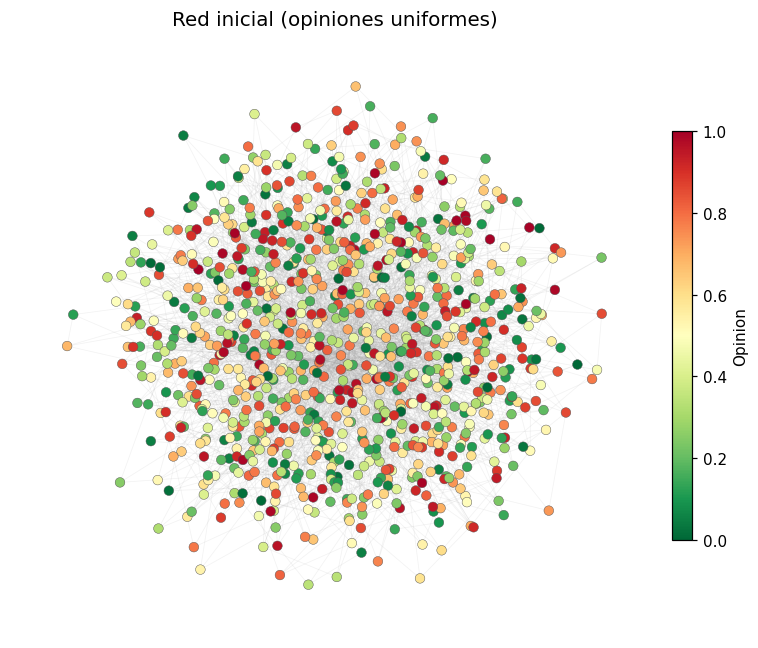

In [3]:
pos = plot_network_opinion(G, title="Red inicial (opiniones uniformes)", layout="spring")

---
## 2 · Modelo HK — solo convergencia de opinión (sin cambio de red)

Aquí vemos qué hace el HK **sin** modificar la estructura de la red.
Solo actualizamos opiniones hasta que el sistema converge.

El parámetro clave es **ε (epsilon)**:  
- ε pequeño → muchos clusters, alta polarización  
- ε grande → consenso

In [4]:
EPSILON = 0.45  # <-- cambia este valor y observa el efecto

result_hk_only = run_simulation(
    G,
    epsilon      = EPSILON,
    rewire       = False,   # sin rewiring: solo HK puro
    max_hk_steps = 500,
    seed         = 42,
)

op_initial  = result_hk_only["snapshots"][0][1]
op_converged = result_hk_only["snapshots"][1][1]

print(f"ε = {EPSILON}")
print(f"Pasos hasta convergencia: {result_hk_only['phases'][0]['steps']}")
print(f"Clusters de opinión: {n_clusters(op_converged)}")
print(f"Varianza final: {opinion_variance(op_converged):.4f}")
print(f"Índice de polarización: {polarization_index(op_converged):.4f}  (0=consenso, 1=máximo)")

ε = 0.45
Pasos hasta convergencia: 41
Clusters de opinión: 4
Varianza final: 0.0007
Índice de polarización: 0.0028  (0=consenso, 1=máximo)


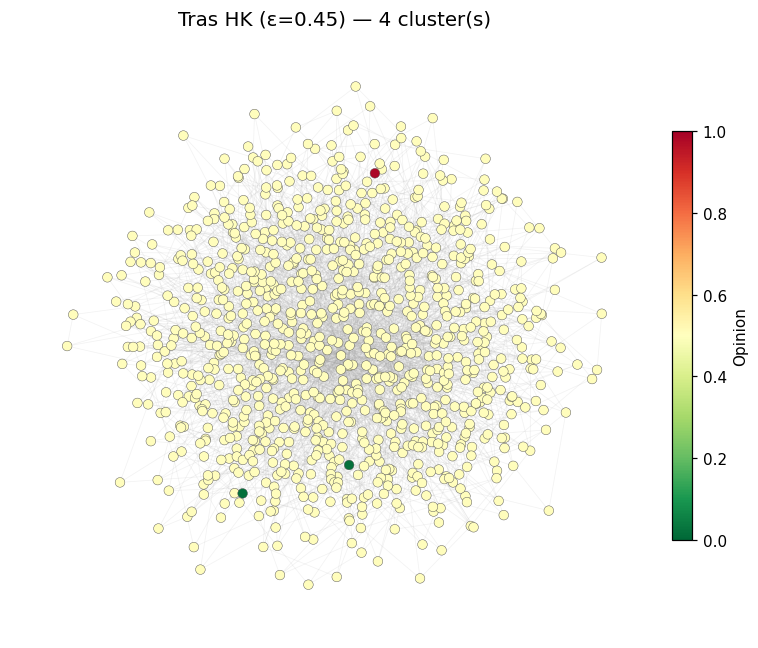

{0: array([-0.08200918, -0.0798869 ]),
 1: array([0.14248435, 0.03218461]),
 2: array([-0.26378149, -0.33318722]),
 3: array([-0.07005513,  0.09460698]),
 4: array([ 0.16909538, -0.04841636]),
 5: array([-0.07865443, -0.06916151]),
 6: array([-0.00282111, -0.05322459]),
 7: array([ 0.02868115, -0.01486793]),
 8: array([-0.01462553, -0.19477545]),
 9: array([ 0.02696929, -0.09362619]),
 10: array([-0.01341244, -0.00373135]),
 11: array([ 0.01779119, -0.18576948]),
 12: array([0.06313663, 0.14432976]),
 13: array([-0.0528135 , -0.03249467]),
 14: array([0.04324393, 0.01428969]),
 15: array([-0.14687938,  0.26098261]),
 16: array([-0.10152093,  0.00211438]),
 17: array([-0.02441638,  0.17601916]),
 18: array([-0.25566228, -0.04963561]),
 19: array([-0.13083065, -0.20575257]),
 20: array([0.18993067, 0.05003976]),
 21: array([0.10683421, 0.1413975 ]),
 22: array([-0.00909496, -0.18667396]),
 23: array([ 0.25648449, -0.13531763]),
 24: array([0.23893894, 0.11571972]),
 25: array([0.0778255 

In [5]:
# Red después de la convergencia HK
plot_network_opinion(
    result_hk_only["G"],
    opinions = op_converged,
    title    = f"Tras HK (ε={EPSILON}) — {n_clusters(op_converged)} cluster(s)",
    pos      = pos,
)

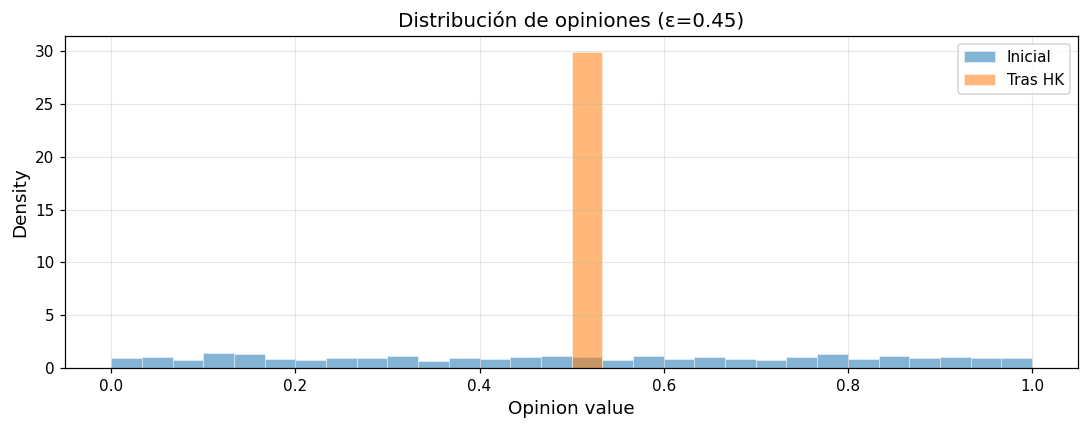

In [6]:
# Histograma: cómo cambia la distribución de opiniones
plot_opinion_histogram({
    "Inicial"    : op_initial,
    "Tras HK"    : op_converged,
}, title=f"Distribución de opiniones (ε={EPSILON})")

### ¿Cómo varía la polarización con ε?

Exploramos distintos valores de epsilon sobre la misma red y vemos cómo cambia la varianza final.

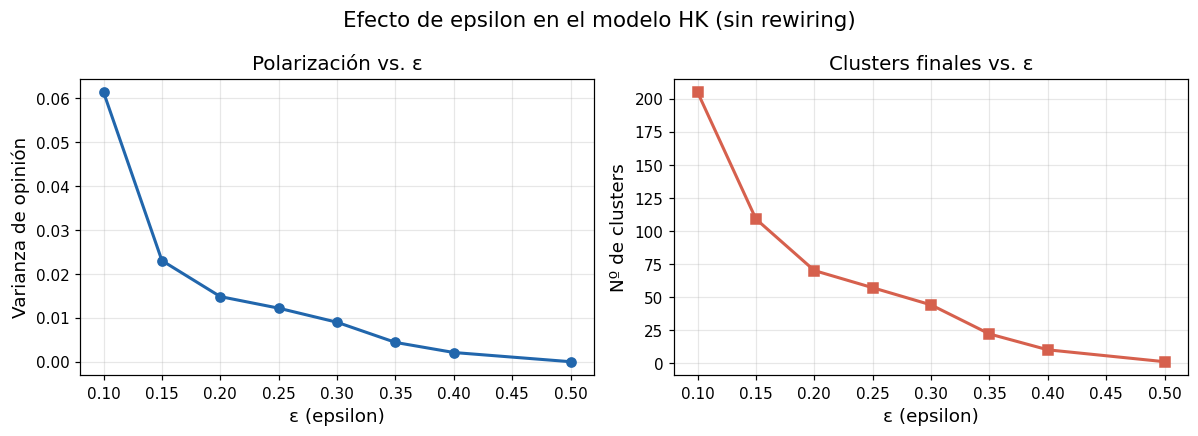

In [7]:
epsilons = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
variances = []
num_clusters = []

for eps in epsilons:
    r = run_simulation(G, epsilon=eps, rewire=False, seed=42)
    final_op = r["snapshots"][-1][1]
    variances.append(opinion_variance(final_op))
    num_clusters.append(n_clusters(final_op))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epsilons, variances, "o-", color="#2166ac", linewidth=2)
ax1.set_xlabel("ε (epsilon)", fontsize=12)
ax1.set_ylabel("Varianza de opinión", fontsize=12)
ax1.set_title("Polarización vs. ε", fontsize=13)
ax1.grid(True, alpha=0.3)

ax2.plot(epsilons, num_clusters, "s-", color="#d6604d", linewidth=2)
ax2.set_xlabel("ε (epsilon)", fontsize=12)
ax2.set_ylabel("Nº de clusters", fontsize=12)
ax2.set_title("Clusters finales vs. ε", fontsize=13)
ax2.yaxis.get_major_locator().set_params(integer=True)
ax2.grid(True, alpha=0.3)

plt.suptitle("Efecto de epsilon en el modelo HK (sin rewiring)", fontsize=14)
plt.tight_layout()
plt.show()

---
## 3 · HK + Rewiring homofílico → cámaras de eco

Ahora activamos el rewiring: en cada ronda, las aristas entre nodos con opiniones **lejanas** se cortan y se reemplaza por aristas entre nodos con opiniones **cercanas**. La red se reconfigura sola para aislar a los grupos.

Parámetros del rewiring:

| Parámetro | Efecto |
|-----------|--------|
| `p_rewire` | Probabilidad de cortar cada arista discordante por ronda. Más alto → más rápido. |
| `rewire_steps` | Número de rondas de rewiring. Más alto → fragmentación más fuerte. |
| `hk_steps_per_rewire` | Pasos de HK entre rondas de rewiring. |

In [8]:
result = run_simulation(
    G,
    epsilon             = 0.05,
    rewire              = True,
    p_rewire            = 0.05,    # <-- prueba 0.02, 0.05, 0.15
    rewire_steps        = 60,      # <-- prueba 20, 60, 120
    hk_steps_per_rewire = 5,
    seed                = 42,
)

op_final = result["snapshots"][-1][1]

print(f"Clusters de opinión finales: {n_clusters(op_final)}")
print(f"Varianza final: {opinion_variance(op_final):.4f}")
print(f"Índice de polarización: {polarization_index(op_final):.4f}")

mod    = result["metrics"].get("modularity",    [float("nan")])[-1]
n_comm = result["metrics"].get("n_communities", [float("nan")])[-1]
if not np.isnan(mod):
    print(f"Modularidad final: {mod:.4f}")
    print(f"Comunidades detectadas: {int(n_comm)}")
else:
    print("Modularidad: N/A  (instala python-louvain para activarla)")


Clusters de opinión finales: 51
Varianza final: 0.0836
Índice de polarización: 0.3344
Modularidad: N/A  (instala python-louvain para activarla)


### Snapshots: evolución de la red en el tiempo

Tres momentos: estado inicial → tras HK puro → tras rewiring.

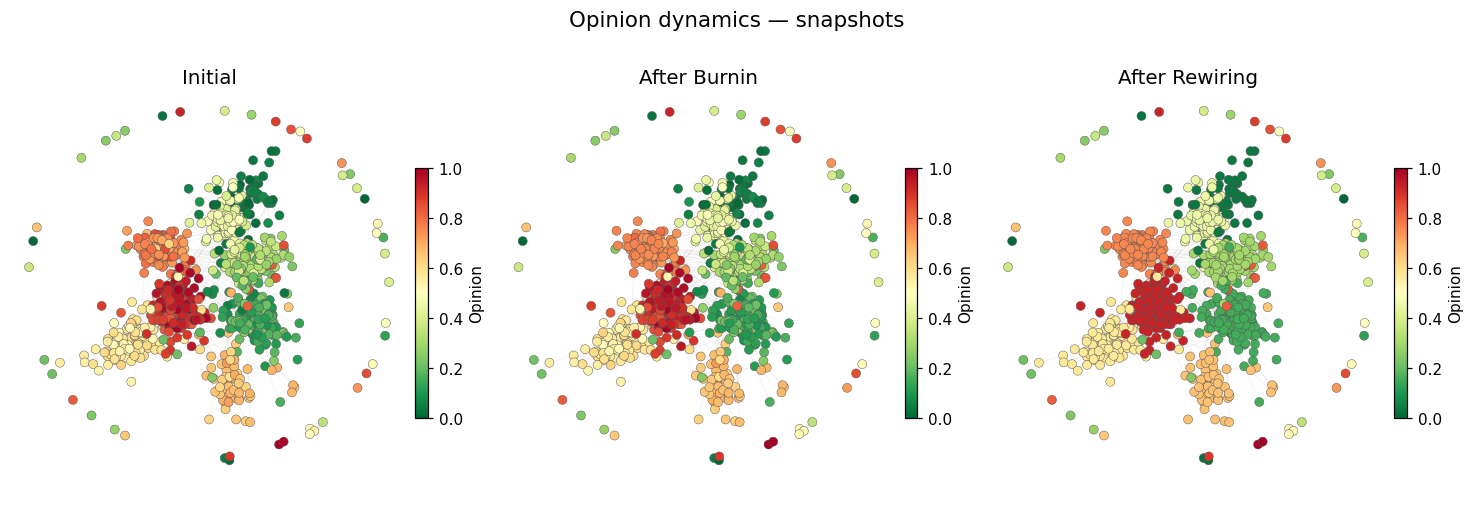

In [9]:
plot_snapshots(
    result["G"],
    result["snapshots"],
    layout   = "spring",
    color_by = "opinion",   # prueba también "community" o "both"
)

### Comunidades detectadas por Louvain — tras el rewiring

Cada color es una comunidad distinta detectada automáticamente.
Cuantas más comunidades aisladas, más fuerte la fragmentación.

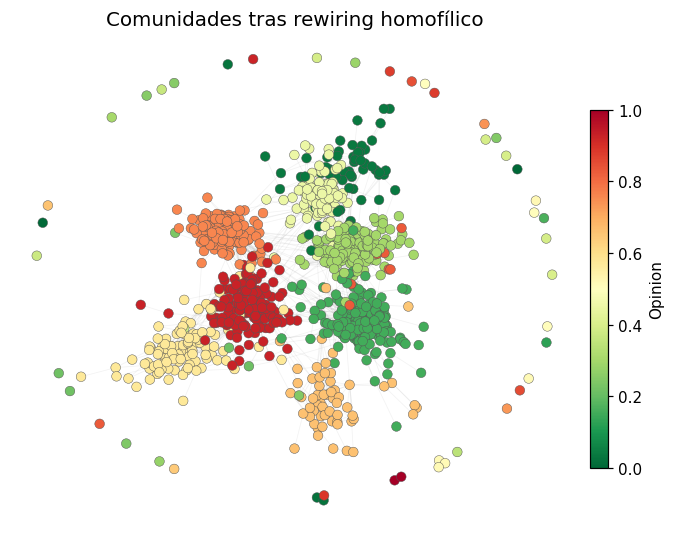

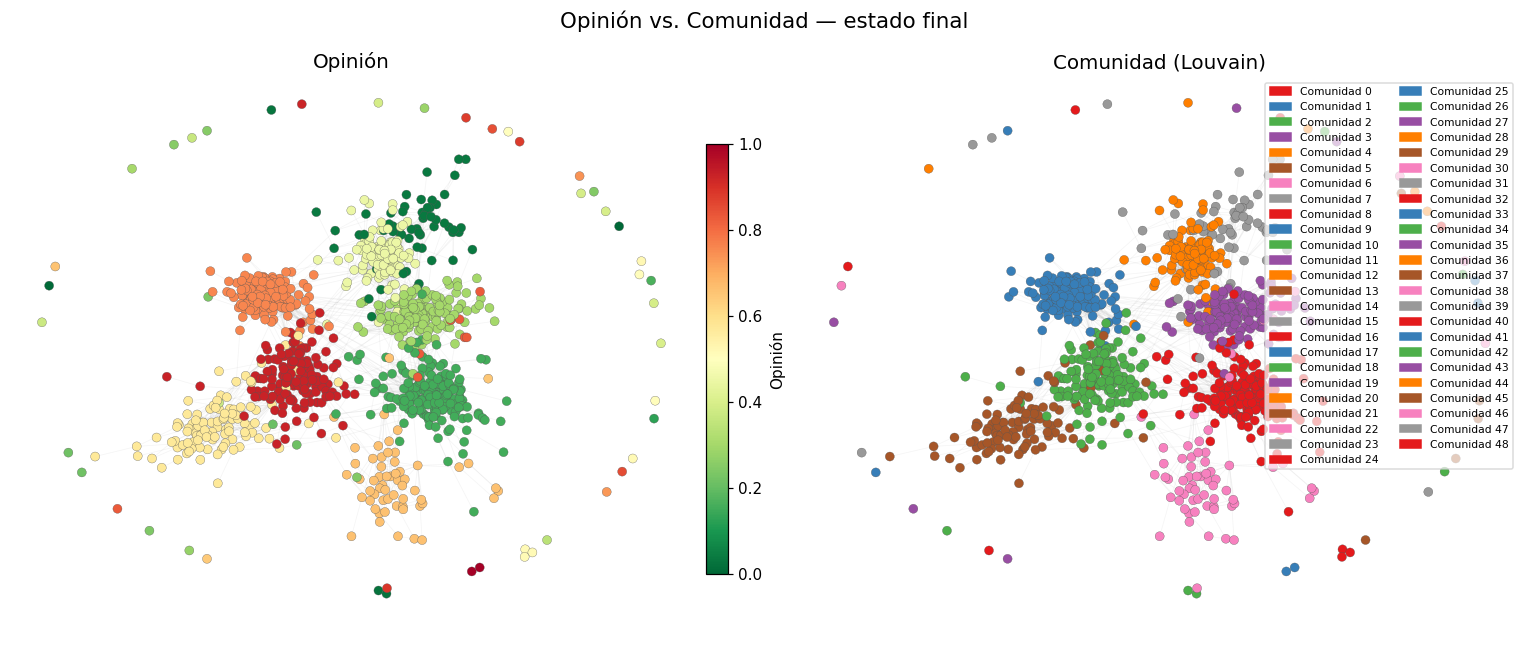

In [10]:
# La red final coloreada por comunidad (Louvain)
plot_network_community(
    result["G"],
    title  = "Comunidades tras rewiring homofílico",
    layout = "spring",
)

# Comparación lado a lado: opinión vs. comunidad
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
import copy, networkx as nx
G_final = result["G"]
op_final_arr = result["snapshots"][-1][1]

from visualization import _get_layout, _opinion_colors, _community_colors
import matplotlib.cm as cm, matplotlib.colors as mcolors, matplotlib.patches as mpatches

from networkx.algorithms.community import greedy_modularity_communities as _nx_comm
from networkx.algorithms.community import modularity as _nx_mod

G_final = result["G"]
op_final_arr = result["snapshots"][-1][1]

# Calcular comunidades con NetworkX
communities = list(_nx_comm(G_final))
partition = {}
for cid, comm in enumerate(communities):
    for node in comm:
        partition[node] = cid
nx.set_node_attributes(G_final, partition, "community")


pos_final = _get_layout(G_final, None, "spring")

# Panel izquierdo — opinión
colors_op = _opinion_colors(op_final_arr)
nx.draw_networkx_edges(G_final, pos_final, ax=ax1, alpha=0.12, edge_color="#aaa", width=0.5)
nx.draw_networkx_nodes(G_final, pos_final, ax=ax1, node_color=colors_op, node_size=35, linewidths=0.2, edgecolors="#555")
sm = cm.ScalarMappable(norm=mcolors.Normalize(0,1), cmap="RdYlGn_r")
plt.colorbar(sm, ax=ax1, fraction=0.03, pad=0.02).set_label("Opinión")
ax1.set_title("Opinión", fontsize=13); ax1.axis("off")

# Panel derecho — comunidad
colors_comm, color_map = _community_colors(G_final)
nx.draw_networkx_edges(G_final, pos_final, ax=ax2, alpha=0.12, edge_color="#aaa", width=0.5)
nx.draw_networkx_nodes(G_final, pos_final, ax=ax2, node_color=colors_comm, node_size=35, linewidths=0.2, edgecolors="#555")
patches = [mpatches.Patch(color=c, label=f"Comunidad {k}") for k, c in color_map.items()]
ax2.legend(handles=patches, fontsize=7, loc="upper right", ncol=2, framealpha=0.7)
ax2.set_title("Comunidad (Louvain)", fontsize=13); ax2.axis("off")

plt.suptitle("Opinión vs. Comunidad — estado final", fontsize=14)
plt.tight_layout()
plt.show()

# Resumen numérico
mod    = result["metrics"].get("modularity",    [float("nan")])[-1]
n_comm = result["metrics"].get("n_communities", [float("nan")])[-1]
if not np.isnan(mod):
    print(f"Modularidad final:      {mod:.4f}")
    print(f"Comunidades detectadas: {int(n_comm)}")


### Métricas a lo largo de la simulación

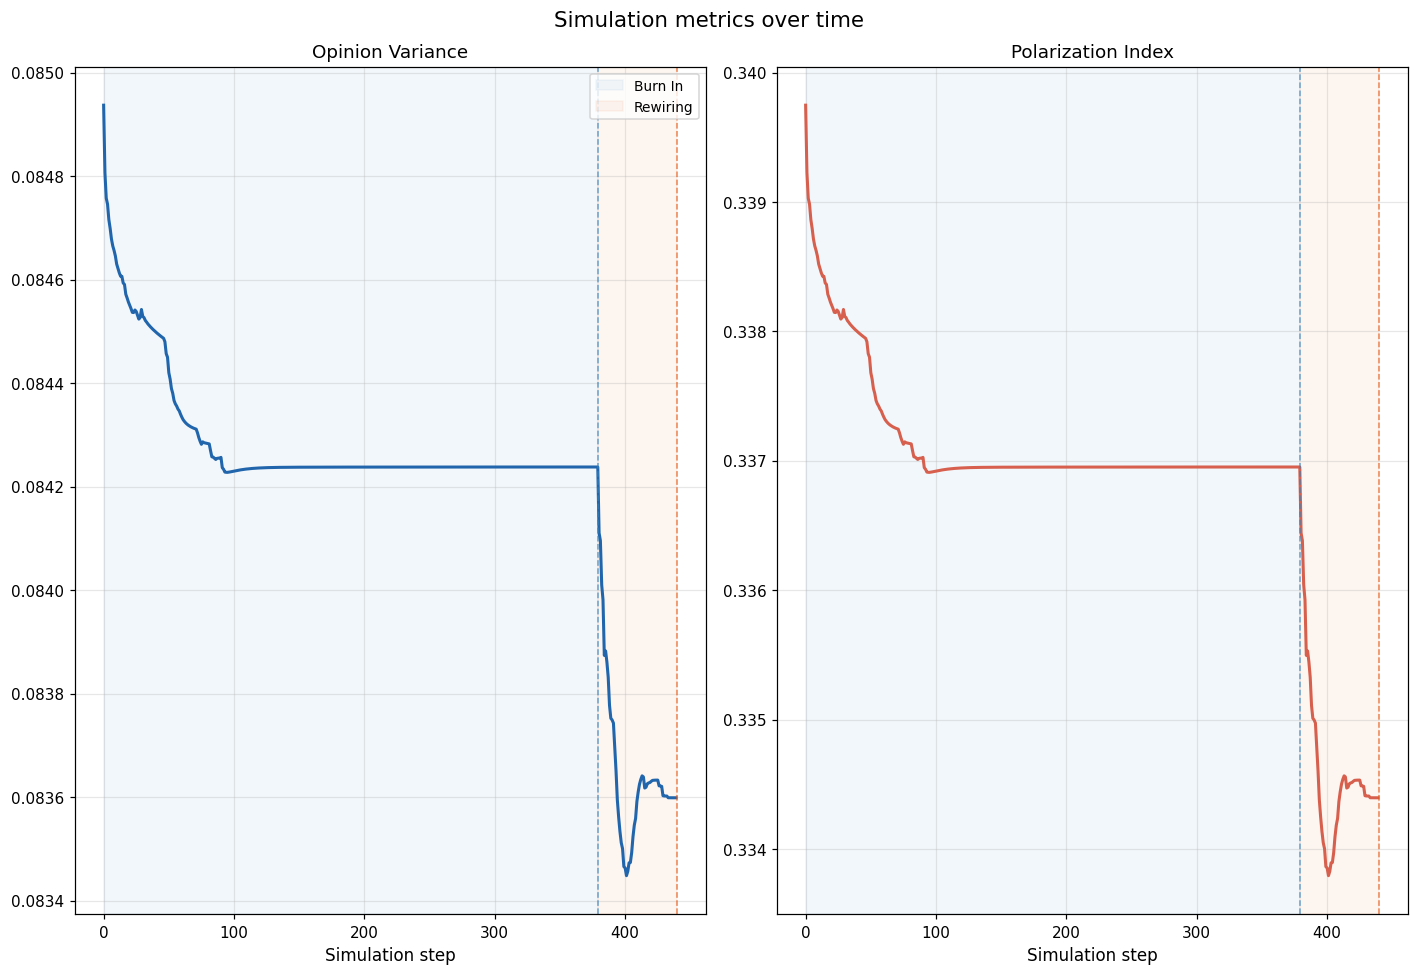

In [11]:
plot_metrics(result)

### Histograma antes y después del rewiring

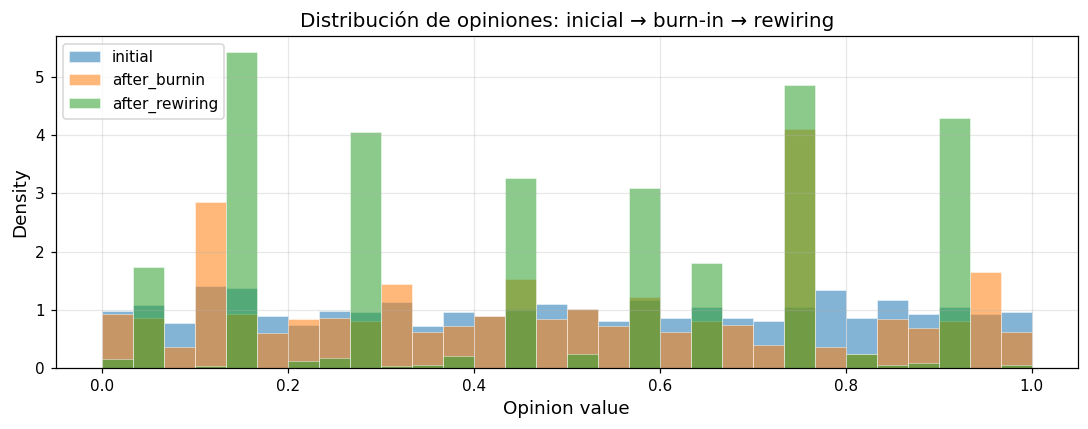

In [12]:
plot_opinion_histogram({
    label: op for label, op in result["snapshots"]
}, title="Distribución de opiniones: inicial → burn-in → rewiring")

---
## 4 · Comparativa de modelos de red

¿Importa la topología? Aplicamos el mismo experimento sobre ER, BA y WS y comparamos la polarización final.

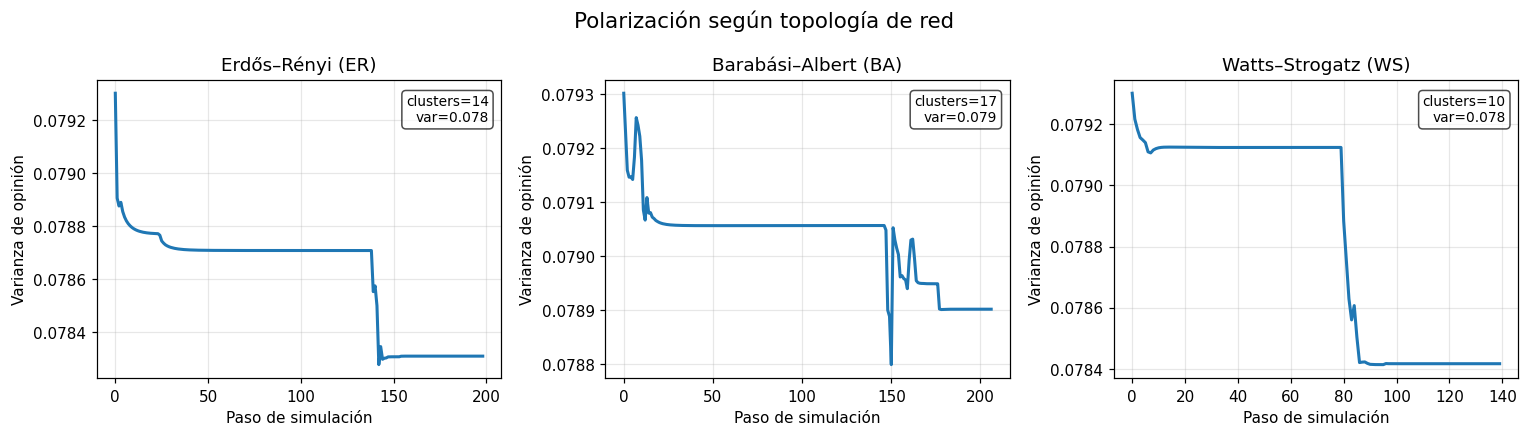

In [13]:
networks = {
    "Erdős–Rényi (ER)": make_network("ER", n=200, p=0.04, opinion="uniform", seed=42),
    "Barabási–Albert (BA)": make_network("BA", n=200, m=3, opinion="uniform", seed=42),
    "Watts–Strogatz (WS)": make_network("WS", n=200, k=6, p=0.1, opinion="uniform", seed=42),
}

SIM_PARAMS = dict(epsilon=0.05, rewire=True, p_rewire=0.08,
                  rewire_steps=60, hk_steps_per_rewire=5, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, Gnet) in zip(axes, networks.items()):
    r = run_simulation(Gnet, **SIM_PARAMS)
    var_series = r["metrics"]["opinion_variance"]
    ax.plot(var_series, linewidth=2)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Paso de simulación")
    ax.set_ylabel("Varianza de opinión")
    ax.grid(True, alpha=0.3)
    final_op = r["snapshots"][-1][1]
    ax.text(0.97, 0.95,
            f"clusters={n_clusters(final_op)}\nvar={opinion_variance(final_op):.3f}",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round', fc='white', alpha=0.7))

plt.suptitle("Polarización según topología de red", fontsize=14)
plt.tight_layout()
plt.show()

---
## 5 · Sandbox — experimenta libremente

Usa esta celda para probar combinaciones de parámetros.

In [ ]:
# --- Cambia lo que quieras aquí ---
G_exp = make_network(
    model   = "BA",       # "ER" | "BA" | "WS"
    n       = 250,
    m       = 4,
    opinion = "bimodal",  # "uniform" | "bimodal" | "clustered"
    seed    = 7,
)

r_exp = run_simulation(
    G_exp,
    epsilon             = 0.20,
    rewire              = True,
    p_rewire            = 0.10,
    rewire_steps        = 50,
    hk_steps_per_rewire = 5,
    seed                = 7,
)

plot_snapshots(r_exp["G"], r_exp["snapshots"], color_by="both")
plot_metrics(r_exp)